<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/assingments/assingment_1/MINE_4210_ADL_202620_T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Taller 1: Clasificación multiclase con un MLP**

### **Contexto y Objetivos**

La obesidad es un problema de salud pública creciente, asociado a enfermedades cardiovasculares, diabetes y otras condiciones crónicas. Identificar el nivel de riesgo de una persona a partir de sus hábitos, sin depender de mediciones clínicas directas como el peso o la estatura, puede ser útil cuando esta información no está disponible o se busca anticipar el riesgo antes de que se manifieste físicamente. En este taller deberán estimar el nivel de obesidad de una persona a partir de variables sociodemográficas y de estilo de vida, como alimentación, actividad física, consumo de alcohol y medio de transporte.

El objetivo de este Taller es construir un perceptrón multicapa (MLP) para esta tarea, siguiendo el proceso de machine learning. Se realizará una búsqueda de hiperparámetros sobre la arquitectura de la red, variando el número de capas ocultas y el número de neuronas por capa.


| Hiperparámetro | Valores para explorar |
|-|-|
| Número de capas ocultas | 1, 2 o 3. |
| Neuronas por capa oculta | 16, 32 o 64 (mismo valor en todas las capas ocultas de una misma arquitectura). |
| Callback obligatorio | Early stopping, monitoreando val_loss, con un valor de patience justificado. |


### **Entregable**

Notebook (.ipynb) con todas las celdas ejecutadas y con todas las indicaciones anteriormente estipuladas en la sección de laboratorios en **Bloque Neón**.



### **Rúbrica**

| Criterio | Peso | Qué se evalúa |
|-|-|-|
| Preprocesamiento de datos | 15 % | Codificación adecuada de las variables categóricas, diferenciando entre nominales y ordinales escalamiento de las variables numéricas; y separación correcta de los conjuntos de entrenamiento, <br> validación y prueba, evitando fuga de información. |
| Implementación del MLP | 15 % | Arquitectura correctamente construida, con función de activación de salida y función de pérdida apropiadas para clasificación multiclase; código funcional y bien organizado. |
| Búsqueda de hiperparámetros | 25 % | Las 9 configuraciones están correctamente implementadas y entrenadas, early stopping está configurado con un valor de patience justificado. Los resultados se presentan de forma <br> clara mediante una tabla o gráfico comparativo. |
| Evaluación y métricas | 15 % | Uso de métricas apropiadas para clasificación multiclase, considerando posibles diferencias en el tamaño de las clases; evaluación final realizada correctamente sobre el conjunto de test.  |
| Interpretación y justificación | 20 % | Justificación de la arquitectura final con base en los resultados y las curvas de entrenamiento y validación; identificación de señales de sobreajuste o subajuste; conclusiones sobre el efecto <br> de la profundidad y el ancho de la red. |
| Calidad y reproducibilidad del notebook | 10 % | El notebook se ejecuta de principio a fin sin errores, está organizado en un orden lógico, no contiene código innecesario e incluye explicaciones breves en Markdown que guían la lectura. |

# PREPROCESAMIENTO DE DATOS

In [43]:
import pandas as pd
import numpy as np

In [44]:
ruta = 'C:\\Users\\Diego\\Documents\\ADL\\taller-1\\talleres-deep-learning-mine-4210\\data\\obesidad.csv'
df_obesidad=pd.read_csv(ruta, sep=";")

In [45]:
df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,Actividad_fisica,Tiempo_pantallas,Alcohol,Transporte,Nivel_obesidad
0,Femenino,21.0,Si,No,2,3,A veces,No,2,No,0,1,No,Transporte_Publico,Peso_Normal
1,Femenino,21.0,Si,No,3,3,A veces,Si,3,Si,3,0,A veces,Transporte_Publico,Peso_Normal
2,Masculino,23.0,Si,No,2,3,A veces,No,2,No,2,1,Frecuentemente,Transporte_Publico,Peso_Normal
3,Masculino,27.0,No,No,3,3,A veces,No,2,No,2,0,Frecuentemente,Caminando,Sobrepeso_Nivel_I
4,Masculino,22.0,No,No,2,1,A veces,No,2,No,0,0,A veces,Transporte_Publico,Sobrepeso_Nivel_II


In [46]:
df_obesidad.describe()

,Edad,Frecuencia_verduras,Comidas_dia,Agua_dia,Actividad_fisica,Tiempo_pantallas
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,2.425970,2.703402,2.011500,1.009104,0.669861
std,6.368801,0.585177,0.797108,0.685322,0.898712,0.673970
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,2.000000,3.000000,2.000000,0.000000,0.000000
50%,22.847618,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [47]:
df_obesidad["Agua_dia"].value_counts(normalize=True)

Agua_dia
2    0.530426
3    0.240537
1    0.229037
Name: proportion, dtype: float64

### Codificación de variables nominales: `Alcohol` y `Transporte`

`Transporte` es una variable nominal: sus categorías (Automovil, Motocicleta, Bicicleta, Caminando, Transporte_Publico) no tienen un orden natural.

`Alcohol` (No, A veces, Frecuentemente, Siempre) sí sugiere un orden de frecuencia, pero en este taller se trata como **nominal** por el espaciado desigual e incierto entre sus categorías. Ambas se codifican con **one-hot encoding**.

In [48]:
variables_nominales = ["Alcohol", "Transporte"]

df_obesidad = pd.get_dummies(df_obesidad, columns=variables_nominales, dtype=int)

df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,...,Nivel_obesidad,Alcohol_A veces,Alcohol_Frecuentemente,Alcohol_No,Alcohol_Siempre,Transporte_Automovil,Transporte_Bicicleta,Transporte_Caminando,Transporte_Motocicleta,Transporte_Transporte_Publico
0,Femenino,21.0,Si,No,2,3,A veces,No,2,No,...,Peso_Normal,0,0,1,0,0,0,0,0,1
1,Femenino,21.0,Si,No,3,3,A veces,Si,3,Si,...,Peso_Normal,1,0,0,0,0,0,0,0,1
2,Masculino,23.0,Si,No,2,3,A veces,No,2,No,...,Peso_Normal,0,1,0,0,0,0,0,0,1
3,Masculino,27.0,No,No,3,3,A veces,No,2,No,...,Sobrepeso_Nivel_I,0,1,0,0,0,0,1,0,0
4,Masculino,22.0,No,No,2,1,A veces,No,2,No,...,Sobrepeso_Nivel_II,1,0,0,0,0,0,0,0,1


In [49]:
df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,...,Nivel_obesidad,Alcohol_A veces,Alcohol_Frecuentemente,Alcohol_No,Alcohol_Siempre,Transporte_Automovil,Transporte_Bicicleta,Transporte_Caminando,Transporte_Motocicleta,Transporte_Transporte_Publico
0,Femenino,21.0,Si,No,2,3,A veces,No,2,No,...,Peso_Normal,0,0,1,0,0,0,0,0,1
1,Femenino,21.0,Si,No,3,3,A veces,Si,3,Si,...,Peso_Normal,1,0,0,0,0,0,0,0,1
2,Masculino,23.0,Si,No,2,3,A veces,No,2,No,...,Peso_Normal,0,1,0,0,0,0,0,0,1
3,Masculino,27.0,No,No,3,3,A veces,No,2,No,...,Sobrepeso_Nivel_I,0,1,0,0,0,0,1,0,0
4,Masculino,22.0,No,No,2,1,A veces,No,2,No,...,Sobrepeso_Nivel_II,1,0,0,0,0,0,0,0,1


### Codificación de variables binarias

`Antecedentes_familiares`, `Come_calorico`, `Fuma`, `Monitorea_calorias` y `Genero` tienen exactamente dos categorías, así que se codifican como una sola columna 0/1 en lugar de one-hot completo (evita una columna redundante, sin introducir ninguna relación de orden porque con 2 categorías no existe ambigüedad de orden).

In [50]:
mapeo_si_no = {"No": 0, "Si": 1}
variables_binarias_si_no = ["Antecedentes_familiares", "Come_calorico", "Fuma", "Monitorea_calorias"]

for col in variables_binarias_si_no:
    df_obesidad[col] = df_obesidad[col].map(mapeo_si_no)

df_obesidad["Genero"] = df_obesidad["Genero"].map({"Femenino": 0, "Masculino": 1})

df_obesidad[variables_binarias_si_no + ["Genero"]].head()

,Antecedentes_familiares,Come_calorico,Fuma,Monitorea_calorias,Genero
0,1,0,0,0,0
1,1,0,1,1,0
2,1,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1


### Codificación de variables ordinales: `Picoteo` y `Agua_dia`

`Picoteo` (No < A veces < Frecuentemente < Siempre) tiene un orden claro de frecuencia, así que se mapea a enteros consecutivos respetando ese orden (no se puede usar el orden alfabético porque no coincide con el orden real).

`Agua_dia` ya viene codificada como entero (1, 2, 3) representando categorías crecientes de consumo de agua, así que no requiere transformación adicional.

In [51]:
mapeo_picoteo = {"No": 0, "A veces": 1, "Frecuentemente": 2, "Siempre": 3}
df_obesidad["Picoteo"] = df_obesidad["Picoteo"].map(mapeo_picoteo)

df_obesidad[["Picoteo", "Agua_dia"]].head()

,Picoteo,Agua_dia
0,1,2
1,1,3
2,1,2
3,1,2
4,1,2


In [52]:
df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,...,Nivel_obesidad,Alcohol_A veces,Alcohol_Frecuentemente,Alcohol_No,Alcohol_Siempre,Transporte_Automovil,Transporte_Bicicleta,Transporte_Caminando,Transporte_Motocicleta,Transporte_Transporte_Publico
0,0,21.0,1,0,2,3,1,0,2,0,...,Peso_Normal,0,0,1,0,0,0,0,0,1
1,0,21.0,1,0,3,3,1,1,3,1,...,Peso_Normal,1,0,0,0,0,0,0,0,1
2,1,23.0,1,0,2,3,1,0,2,0,...,Peso_Normal,0,1,0,0,0,0,0,0,1
3,1,27.0,0,0,3,3,1,0,2,0,...,Sobrepeso_Nivel_I,0,1,0,0,0,0,1,0,0
4,1,22.0,0,0,2,1,1,0,2,0,...,Sobrepeso_Nivel_II,1,0,0,0,0,0,0,0,1


## SEPARACIÓN EN TRAIN / VALIDATION / TEST

Separamos el dataset en tres conjuntos **antes** de escalar las variables numéricas, para evitar fuga de información (el escalador se debe ajustar únicamente con el conjunto de entrenamiento):

- **Entrenamiento (70%)**: se usa para ajustar los pesos de la red.
- **Validación (15%)**: se usa para comparar las 9 configuraciones de hiperparámetros (número de capas, neuronas por capa, optimizador, activación de salida, etc.) y para el early stopping, sin tocar el conjunto de prueba.
- **Prueba (15%)**: se usa **una sola vez**, al final, sobre el modelo ya elegido, para estimar qué tan bien generaliza.

Usamos `train_test_split` de scikit-learn dos veces (primero separamos test, luego dividimos el resto en train/val), con `stratify` sobre `Nivel_obesidad` para que las proporciones de cada clase se mantengan en los tres conjuntos, dado que hay leves diferencias en el tamaño de las clases.

In [53]:
from sklearn.model_selection import train_test_split

X = df_obesidad.drop(columns=["Nivel_obesidad"])
y = df_obesidad["Nivel_obesidad"]

# Primero separamos el conjunto de prueba (15% del total)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Del 85% restante, separamos validación (15% del total => 15/85 del restante) y entrenamiento (70% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0] / len(X):.1%})")
print(f"Val:   {X_val.shape[0]} filas ({X_val.shape[0] / len(X):.1%})")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0] / len(X):.1%})")

Train: 1460 filas (70.0%)
Val:   313 filas (15.0%)
Test:  314 filas (15.0%)


In [54]:
# Verificamos que la estratificación preservó las proporciones de clase en los 3 conjuntos
pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Val": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True),
})

,Train,Val,Test
Nivel_obesidad,,,
Obesidad_Tipo_I,0.167808,0.169329,0.168790
Obesidad_Tipo_III,0.154795,0.156550,0.156051
Obesidad_Tipo_II,0.141781,0.143770,0.143312
Sobrepeso_Nivel_II,0.139041,0.137380,0.140127
Peso_Normal,0.135616,0.134185,0.133758
Sobrepeso_Nivel_I,0.132877,0.130990,0.130573
Peso_Insuficiente,0.128082,0.127796,0.127389


## ESCALAMIENTO DE VARIABLES NUMÉRICAS

Estandarizamos (media 0, varianza 1) `Edad` junto con las variables ordinales numéricas (`Frecuencia_verduras`, `Comidas_dia`, `Agua_dia`, `Actividad_fisica`, `Tiempo_pantallas`, `Picoteo`), para que ninguna domine el entrenamiento solo por tener una escala más grande. Las binarias y las one-hot (`Alcohol_*`, `Transporte_*`) se dejan como están (0/1).

El `StandardScaler` se **ajusta únicamente con `X_train`** y luego se aplica (transform, no fit) sobre `X_val` y `X_test`, para no filtrar información de validación/prueba hacia el preprocesamiento.

In [55]:
from sklearn.preprocessing import StandardScaler

variables_numericas = [
    "Edad", "Frecuencia_verduras", "Comidas_dia",
    "Agua_dia", "Actividad_fisica", "Tiempo_pantallas", "Picoteo",
]

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_val[variables_numericas] = scaler.transform(X_val[variables_numericas])
X_test[variables_numericas] = scaler.transform(X_test[variables_numericas])

X_train[variables_numericas].describe()

,Edad,Frecuencia_verduras,Comidas_dia,Agua_dia,Actividad_fisica,Tiempo_pantallas,Picoteo
count,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03
mean,9.368457e-17,-6.205082e-17,-2.871371e-16,-7.665101e-17,2.676702e-17,4.623395e-17,2.433366e-18
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00
min,-1.458845e+00,-2.445740e+00,-2.187204e+00,-1.432652e+00,-1.117123e+00,-9.930352e-01,-2.503294e+00
25%,-7.038946e-01,-7.323137e-01,3.582866e-01,1.587427e-02,-1.117123e+00,-9.930352e-01,-3.187098e-01
50%,-2.422895e-01,-7.323137e-01,3.582866e-01,1.587427e-02,2.184319e-02,4.818696e-01,-3.187098e-01
75%,2.495748e-01,9.811125e-01,3.582866e-01,1.587427e-02,1.160809e+00,4.818696e-01,-3.187098e-01
max,5.685456e+00,9.811125e-01,1.631032e+00,1.464401e+00,2.299775e+00,1.956774e+00,4.050458e+00


# Implementación del MLP

In [56]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

label_encoder.classes_

array(['Obesidad_Tipo_I', 'Obesidad_Tipo_II', 'Obesidad_Tipo_III',
       'Peso_Insuficiente', 'Peso_Normal', 'Sobrepeso_Nivel_I',
       'Sobrepeso_Nivel_II'], dtype=object)

### Función de activación de salida y función de pérdida

`Nivel_obesidad` es un problema de clasificación **multiclase de una sola etiqueta** (cada persona pertenece a exactamente una de las 7 categorías, no a varias a la vez). Por eso:

- **Softmax** en la capa de salida: convierte los logits en una distribución de probabilidad sobre las 7 clases (todas positivas y suman 1), a diferencia de sigmoid, que trataría cada clase como independiente (apropiado para multi-etiqueta, no aquí).
- **Entropía cruzada** como función de pérdida: es la función de costo estándar para clasificación con salida softmax. Usamos `sparse_categorical_crossentropy` porque codificamos el target como enteros (0-6) con `LabelEncoder` en vez de one-hot — es matemáticamente equivalente a `categorical_crossentropy` con targets one-hot, pero evita el paso extra de `to_categorical`.

La arquitectura se define con una función `build_model` para poder instanciar fácilmente las 9 combinaciones de (número de capas ocultas, neuronas por capa) en la búsqueda de hiperparámetros.

In [57]:
import sys
# !{sys.executable} -m pip install tensorflow
# !{sys.executable} -m pip install keras

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_model(n_hidden_layers, n_neurons, input_dim, n_classes):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for _ in range(n_hidden_layers):
        model.add(layers.Dense(n_neurons, activation="relu"))

    model.add(layers.Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [59]:
# Ejemplo de instanciación (una de las 9 combinaciones que se probarán en la búsqueda de hiperparámetros)
n_features = X_train.shape[1]
n_classes = len(label_encoder.classes_)

modelo_ejemplo = build_model(n_hidden_layers=2, n_neurons=32, input_dim=n_features, n_classes=n_classes)
modelo_ejemplo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,991 (7.78 KB)

 Trainable params: 1,991 (7.78 KB)

 Non-trainable params: 0 (0.00 B)

# Búsqueda de hiperparámetros

Probamos las 9 combinaciones de (número de capas ocultas ∈ {1,2,3}) × (neuronas por capa ∈ {16,32,64}), reutilizando `build_model`. Cada modelo se entrena con un `EarlyStopping` propio que monitorea `val_loss`, con **`patience=15`** y `restore_best_weights=True`.

¿Por qué `patience=15`? El conjunto de validación es pequeño (313 filas), así que `val_loss` fluctúa de época a época por ruido normal del entrenamiento; un valor bajo (2-3) arriesga parar antes de que el modelo realmente converja. Como los modelos son pequeños y entrenan rápido, el costo de esperar 15 épocas sin mejora es bajo, así que preferimos ese margen antes que arriesgar una parada prematura. Fijamos un tope de 150 épocas para que sea el early stopping —no el límite— el que decida cuándo parar.

Para cada combinación guardamos el mejor `val_loss`/`val_accuracy` (según la época que `restore_best_weights` recupera) y cuántas épocas tardó en converger.

In [60]:
import itertools
import time

n_capas_ocultas_opciones = [1, 2, 3]
n_neuronas_opciones = [16, 32, 64]

resultados = []
historias = {}

for n_capas, n_neuronas in itertools.product(n_capas_ocultas_opciones, n_neuronas_opciones):
    keras.utils.set_random_seed(42)

    modelo = build_model(
        n_hidden_layers=n_capas,
        n_neurons=n_neuronas,
        input_dim=n_features,
        n_classes=n_classes,
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )

    inicio = time.time()
    historia = modelo.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=150,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
    )
    duracion = time.time() - inicio

    mejor_epoca = int(np.argmin(historia.history["val_loss"]))
    historias[(n_capas, n_neuronas)] = historia.history

    resultados.append({
        "n_capas_ocultas": n_capas,
        "n_neuronas": n_neuronas,
        "val_loss": historia.history["val_loss"][mejor_epoca],
        "val_accuracy": historia.history["val_accuracy"][mejor_epoca],
        "epocas_entrenadas": len(historia.history["val_loss"]),
        "mejor_epoca": mejor_epoca + 1,
        "tiempo_seg": round(duracion, 1),
    })

    print(
        f"Capas={n_capas}, Neuronas={n_neuronas} -> "
        f"val_loss={resultados[-1]['val_loss']:.4f}, "
        f"val_accuracy={resultados[-1]['val_accuracy']:.4f}, "
        f"epocas={resultados[-1]['epocas_entrenadas']}"
    )

Capas=1, Neuronas=16 -> val_loss=0.9684, val_accuracy=0.6773, epocas=150
Capas=1, Neuronas=32 -> val_loss=0.8675, val_accuracy=0.6837, epocas=126
Capas=1, Neuronas=64 -> val_loss=0.8561, val_accuracy=0.7380, epocas=104
Capas=2, Neuronas=16 -> val_loss=0.9179, val_accuracy=0.6837, epocas=93
Capas=2, Neuronas=32 -> val_loss=0.9356, val_accuracy=0.6486, epocas=55
Capas=2, Neuronas=64 -> val_loss=0.8436, val_accuracy=0.7188, epocas=41
Capas=3, Neuronas=16 -> val_loss=0.8910, val_accuracy=0.7125, epocas=87
Capas=3, Neuronas=32 -> val_loss=0.9265, val_accuracy=0.6581, epocas=40
Capas=3, Neuronas=64 -> val_loss=0.7909, val_accuracy=0.7380, epocas=31


In [61]:
df_resultados = pd.DataFrame(resultados).sort_values("val_loss").reset_index(drop=True)
df_resultados

,n_capas_ocultas,n_neuronas,val_loss,val_accuracy,epocas_entrenadas,mejor_epoca,tiempo_seg
0,3,64,0.790892,0.738019,31,16,6.7
1,2,64,0.843617,0.718850,41,26,7.0
2,1,64,0.856084,0.738019,104,89,15.0
3,1,32,0.867498,0.683706,126,111,17.1
4,3,16,0.891005,0.712460,87,72,13.2
5,2,16,0.917925,0.683706,93,78,13.7
6,3,32,0.926462,0.658147,40,25,6.4
7,2,32,0.935558,0.648562,55,40,7.6
8,1,16,0.968365,0.677316,150,141,21.3


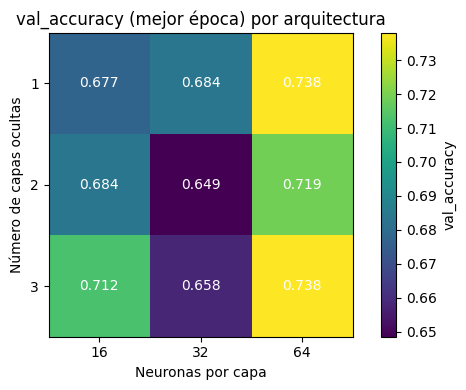

In [62]:
import matplotlib.pyplot as plt

pivot_accuracy = df_resultados.pivot(index="n_capas_ocultas", columns="n_neuronas", values="val_accuracy")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot_accuracy.values, cmap="viridis")

ax.set_xticks(range(len(pivot_accuracy.columns)))
ax.set_xticklabels(pivot_accuracy.columns)
ax.set_yticks(range(len(pivot_accuracy.index)))
ax.set_yticklabels(pivot_accuracy.index)
ax.set_xlabel("Neuronas por capa")
ax.set_ylabel("Número de capas ocultas")
ax.set_title("val_accuracy (mejor época) por arquitectura")

for i in range(pivot_accuracy.shape[0]):
    for j in range(pivot_accuracy.shape[1]):
        ax.text(j, i, f"{pivot_accuracy.values[i, j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, label="val_accuracy")
plt.tight_layout()
plt.show()